# VLM and Non-VLM Models Comparison

This notebook compares vision-language models with traditional computer vision models on driving-scene analysis.


In [1]:

!pip install -U "bitsandbytes>=0.46.1" "transformers>=4.45.0" accelerate qwen-vl-utils ultralytics opencv-python datasets pandas matplotlib pillow psutil

In [2]:
import os
import time
import gc
import cv2
import psutil
import zipfile
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset
from ultralytics import YOLO
from transformers import (
    AutoProcessor,
    LlavaForConditionalGeneration,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig,
)
from qwen_vl_utils import process_vision_info

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Imports successful.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Imports successful.


In [3]:
base_dir = Path.cwd()
test_image_dir = base_dir / "test_images"
output_dir = base_dir / "outputs"

test_image_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Base directory:", base_dir)
print("Test image directory:", test_image_dir)
print("Output directory:", output_dir)

Base directory: /kaggle/working
Test image directory: /kaggle/working/test_images
Output directory: /kaggle/working/outputs


## 1. Loading KITTI Dataset Sample

README.md:   0%|          | 0.00/966 [00:00<?, ?B/s]

data/train-00000-of-00010.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00001-of-00010.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00010.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00003-of-00010.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/253M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/250M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6347 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/423 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/711 [00:00<?, ? examples/s]

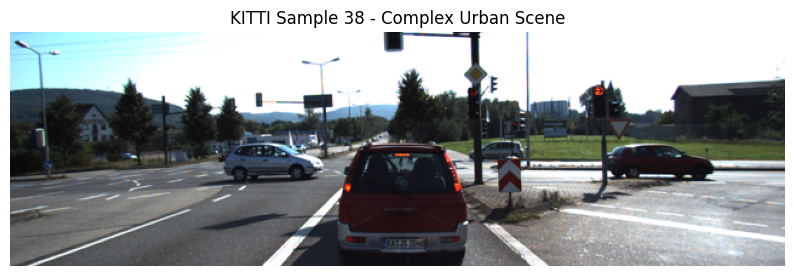

Saved image: /kaggle/working/test_images/sample11_complex_scene.png
Image size: (640, 193)


In [4]:
dataset = load_dataset("dpdl-benchmark/kitti", split="validation")

sample_index = 38
image = dataset[sample_index]["image"].convert("RGB")

# Resize to reduce VLM memory use.
max_width = 640
if image.width > max_width:
    ratio = max_width / image.width
    new_height = int(image.height * ratio)
    image = image.resize((max_width, new_height))

image_path = str(test_image_dir / "sample11_complex_scene.png")
image.save(image_path)

plt.figure(figsize=(10, 5))
plt.imshow(image)
plt.axis("off")
plt.title("KITTI Sample 38 - Complex Urban Scene")
plt.show()

print("Saved image:", image_path)
print("Image size:", image.size)

In [5]:
hazard_prompt = """
Identify visible hazards in this driving scene and recommend what the ego vehicle should do.

Mention:
1. Visible hazards
2. Road users and behaviour
3. Why the scene may be risky
4. Immediate action for the ego vehicle

Be concise.
"""

all_results = []


def get_resource_snapshot():
    ram_used_gb = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)

    if torch.cuda.is_available():
        vram_used_gb = torch.cuda.memory_allocated() / (1024 ** 3)
    else:
        vram_used_gb = 0

    return round(ram_used_gb, 3), round(vram_used_gb, 3)

## 2. Non-VLM Model 1: YOLOv8n

In [6]:
yolo_model = YOLO("yolov8n.pt")

start_time = time.time()
yolo_results = yolo_model(image_path)
yolo_time = time.time() - start_time

detected_objects = []

for result in yolo_results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]
        confidence = float(box.conf[0])
        detected_objects.append(f"{class_name} ({round(confidence, 3)})")

yolo_output = ", ".join(detected_objects)

if yolo_output == "":
    yolo_output = "No objects detected"

yolo_image_path = str(output_dir / "yolo_sample11.png")

for result in yolo_results:
    annotated_image = result.plot()
    cv2.imwrite(yolo_image_path, annotated_image)

ram_used, vram_used = get_resource_snapshot()

yolo_result = {
    "model": "YOLOv8n",
    "model_type": "Non-VLM object detector",
    "output_type": "Bounding boxes, labels, confidence scores",
    "main_output": yolo_output,
    "inference_time_sec": round(yolo_time, 3),
    "ram_used_gb": ram_used,
    "vram_used_gb": vram_used,
    "hazard_reasoning": "No",
    "action_recommendation": "No",
}

all_results.append(yolo_result)

print(yolo_result)
print("Saved YOLO image:", yolo_image_path)


image 1/1 /kaggle/working/test_images/sample11_complex_scene.png: 224x640 1 person, 7 cars, 1 traffic light, 66.5ms
Speed: 3.7ms preprocess, 66.5ms inference, 36.6ms postprocess per image at shape (1, 3, 224, 640)
{'model': 'YOLOv8n', 'model_type': 'Non-VLM object detector', 'output_type': 'Bounding boxes, labels, confidence scores', 'main_output': 'car (0.893), car (0.891), car (0.831), person (0.653), traffic light (0.582), car (0.404), car (0.335), car (0.285), car (0.275)', 'inference_time_sec': 1.795, 'ram_used_gb': 2.284, 'vram_used_gb': 0.012, 'hazard_reasoning': 'No', 'action_recommendation': 'No'}
Saved YOLO image: /kaggle/working/outputs/yolo_sample11.png


## 3. Non-VLM Model 2: OpenCV Canny + Contours

In [7]:
start_time = time.time()

image_cv = cv2.imread(image_path)
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)

opencv_time = time.time() - start_time

opencv_edges_path = str(output_dir / "opencv_edges_sample11.png")
opencv_contours_path = str(output_dir / "opencv_contours_sample11.png")

cv2.imwrite(opencv_edges_path, edges)

contour_image = image_cv.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 1)
cv2.imwrite(opencv_contours_path, contour_image)

ram_used, vram_used = get_resource_snapshot()

opencv_result = {
    "model": "OpenCV Canny + Contours",
    "model_type": "Traditional computer vision",
    "output_type": "Edges and contours",
    "main_output": f"{len(contours)} contours detected",
    "inference_time_sec": round(opencv_time, 3),
    "ram_used_gb": ram_used,
    "vram_used_gb": vram_used,
    "hazard_reasoning": "No",
    "action_recommendation": "No",
}

all_results.append(opencv_result)

print(opencv_result)
print("Saved OpenCV edges image:", opencv_edges_path)
print("Saved OpenCV contours image:", opencv_contours_path)

{'model': 'OpenCV Canny + Contours', 'model_type': 'Traditional computer vision', 'output_type': 'Edges and contours', 'main_output': '323 contours detected', 'inference_time_sec': 0.027, 'ram_used_gb': 2.287, 'vram_used_gb': 0.012, 'hazard_reasoning': 'No', 'action_recommendation': 'No'}
Saved OpenCV edges image: /kaggle/working/outputs/opencv_edges_sample11.png
Saved OpenCV contours image: /kaggle/working/outputs/opencv_contours_sample11.png


## 4. Vision-Language Model 1: Qwen2.5-VL-7B-Instruct

In [8]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

qwen_model_name = "Qwen/Qwen2.5-VL-7B-Instruct"

qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    qwen_model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

qwen_processor = AutoProcessor.from_pretrained(
    qwen_model_name,
    min_pixels=128 * 28 * 28,
    max_pixels=384 * 28 * 28,
)

print("Qwen loaded.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen loaded.


In [9]:
qwen_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": hazard_prompt},
        ],
    }
]

start_time = time.time()

qwen_text = qwen_processor.apply_chat_template(
    qwen_messages,
    tokenize=False,
    add_generation_prompt=True,
)

qwen_image_inputs, qwen_video_inputs = process_vision_info(qwen_messages)

qwen_inputs = qwen_processor(
    text=[qwen_text],
    images=qwen_image_inputs,
    videos=qwen_video_inputs,
    padding=True,
    return_tensors="pt",
).to(qwen_model.device)

with torch.no_grad():
    qwen_generated_ids = qwen_model.generate(
        **qwen_inputs,
        max_new_tokens=80,
        do_sample=False,
    )

qwen_generated_ids_trimmed = [
    output_ids[len(input_ids):]
    for input_ids, output_ids in zip(qwen_inputs.input_ids, qwen_generated_ids)
]

qwen_output = qwen_processor.batch_decode(
    qwen_generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

qwen_time = time.time() - start_time
ram_used, vram_used = get_resource_snapshot()

qwen_result = {
    "model": "Qwen2.5-VL-7B-Instruct",
    "model_type": "VLM",
    "output_type": "Hazard reasoning and action recommendation",
    "main_output": qwen_output,
    "inference_time_sec": round(qwen_time, 3),
    "ram_used_gb": ram_used,
    "vram_used_gb": vram_used,
    "hazard_reasoning": "Yes",
    "action_recommendation": "Yes",
}

all_results.append(qwen_result)

print(qwen_result)

{'model': 'Qwen2.5-VL-7B-Instruct', 'model_type': 'VLM', 'output_type': 'Hazard reasoning and action recommendation', 'main_output': '1. **Visible Hazards:**\n   - A red car is stopped at the intersection, waiting to turn right.\n   - A silver car is approaching from the left, likely turning left.\n   - Traffic lights are present but not clearly showing signals.\n\n2. **Road Users and Behaviour:**\n   - The red car appears to be cautiously waiting for the right signal to turn.\n   - The', 'inference_time_sec': 11.15, 'ram_used_gb': 3.028, 'vram_used_gb': 1.503, 'hazard_reasoning': 'Yes', 'action_recommendation': 'Yes'}


In [10]:
del qwen_model
del qwen_processor
del qwen_inputs
del qwen_generated_ids

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Qwen cleared from memory.")

Qwen cleared from memory.


## 5. Vision-Language Model 2: LLaVA-1.5-7B

In [11]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

llava_model_name = "llava-hf/llava-1.5-7b-hf"

llava_model = LlavaForConditionalGeneration.from_pretrained(
    llava_model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

llava_processor = AutoProcessor.from_pretrained(llava_model_name)

print("LLaVA loaded.")

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

LLaVA loaded.


In [12]:
image_for_llava = Image.open(image_path).convert("RGB")
llava_prompt = f"USER: <image>\n{hazard_prompt}\nASSISTANT:"

start_time = time.time()

llava_inputs = llava_processor(
    images=image_for_llava,
    text=llava_prompt,
    return_tensors="pt",
).to(llava_model.device)

with torch.no_grad():
    llava_generated_ids = llava_model.generate(
        **llava_inputs,
        max_new_tokens=80,
        do_sample=False,
    )

llava_output = llava_processor.batch_decode(
    llava_generated_ids,
    skip_special_tokens=True,
)[0]

llava_time = time.time() - start_time
ram_used, vram_used = get_resource_snapshot()

llava_result = {
    "model": "LLaVA-1.5-7B",
    "model_type": "VLM",
    "output_type": "Hazard reasoning and action recommendation",
    "main_output": llava_output,
    "inference_time_sec": round(llava_time, 3),
    "ram_used_gb": ram_used,
    "vram_used_gb": vram_used,
    "hazard_reasoning": "Yes",
    "action_recommendation": "Yes, usually general",
}

all_results.append(llava_result)

print(llava_result)

{'model': 'LLaVA-1.5-7B', 'model_type': 'VLM', 'output_type': 'Hazard reasoning and action recommendation', 'main_output': 'USER:  \n\nIdentify visible hazards in this driving scene and recommend what the ego vehicle should do.\n\nMention:\n1. Visible hazards\n2. Road users and behaviour\n3. Why the scene may be risky\n4. Immediate action for the ego vehicle\n\nBe concise.\n\nASSISTANT: 1. Visible hazards: A red car is stopped at a traffic light, and there are other cars and pedestrians around.\n2. Road users and behavior: The red car is stopped at a traffic light, and other cars are either stopped or moving. Pedestrians are also present in the scene.\n3. Why the scene may be risky:', 'inference_time_sec': 7.874, 'ram_used_gb': 2.704, 'vram_used_gb': 1.529, 'hazard_reasoning': 'Yes', 'action_recommendation': 'Yes, usually general'}


## 6. Results Tables

In [13]:
results_df = pd.DataFrame(all_results)
results_df

,model,model_type,output_type,main_output,inference_time_sec,ram_used_gb,vram_used_gb,hazard_reasoning,action_recommendation
0,YOLOv8n,Non-VLM object detector,"Bounding boxes, labels, confidence scores","car (0.893), car (0.891), car (0.831), person ...",1.795,2.284,0.012,No,No
1,OpenCV Canny + Contours,Traditional computer vision,Edges and contours,323 contours detected,0.027,2.287,0.012,No,No
2,Qwen2.5-VL-7B-Instruct,VLM,Hazard reasoning and action recommendation,1. **Visible Hazards:**\n - A red car is sto...,11.150,3.028,1.503,Yes,Yes
3,LLaVA-1.5-7B,VLM,Hazard reasoning and action recommendation,USER: \n\nIdentify visible hazards in this dr...,7.874,2.704,1.529,Yes,"Yes, usually general"


In [14]:
full_results_path = base_dir / "full_results.csv"
results_df.to_csv(full_results_path, index=False)

print("Saved:", full_results_path)

Saved: /kaggle/working/full_results.csv


In [15]:
table_2 = results_df[
    [
        "model",
        "model_type",
        "main_output",
        "inference_time_sec",
        "hazard_reasoning",
        "action_recommendation",
    ]
]

table_2_path = base_dir / "table_2_hazard_understanding.csv"
table_2.to_csv(table_2_path, index=False)

print("Saved:", table_2_path)
table_2

Saved: /kaggle/working/table_2_hazard_understanding.csv


,model,model_type,main_output,inference_time_sec,hazard_reasoning,action_recommendation
0,YOLOv8n,Non-VLM object detector,"car (0.893), car (0.891), car (0.831), person ...",1.795,No,No
1,OpenCV Canny + Contours,Traditional computer vision,323 contours detected,0.027,No,No
2,Qwen2.5-VL-7B-Instruct,VLM,1. **Visible Hazards:**\n - A red car is sto...,11.150,Yes,Yes
3,LLaVA-1.5-7B,VLM,USER: \n\nIdentify visible hazards in this dr...,7.874,Yes,"Yes, usually general"


In [16]:
table_3_rows = [
    {
        "Model": "Qwen2.5-VL-7B-Instruct",
        "Detects known objects": "Moderate",
        "Describes unusual context": "Strong",
        "Infers possible risk": "Strong",
        "Explains recommended action": "Strong",
    },
    {
        "Model": "YOLOv8n",
        "Detects known objects": "Strong",
        "Describes unusual context": "Weak",
        "Infers possible risk": "Weak",
        "Explains recommended action": "No",
    },
    {
        "Model": "OpenCV Canny + Contours",
        "Detects known objects": "Weak",
        "Describes unusual context": "Weak",
        "Infers possible risk": "Weak",
        "Explains recommended action": "No",
    },
]

if "LLaVA-1.5-7B" in results_df["model"].values:
    table_3_rows.insert(
        1,
        {
            "Model": "LLaVA-1.5-7B",
            "Detects known objects": "Moderate",
            "Describes unusual context": "Moderate/Strong",
            "Infers possible risk": "Moderate",
            "Explains recommended action": "Moderate",
        },
    )

table_3 = pd.DataFrame(table_3_rows)

table_3_path = base_dir / "table_3_ambiguous_scene_comparison.csv"
table_3.to_csv(table_3_path, index=False)

print("Saved:", table_3_path)
table_3

Saved: /kaggle/working/table_3_ambiguous_scene_comparison.csv


,Model,Detects known objects,Describes unusual context,Infers possible risk,Explains recommended action
0,Qwen2.5-VL-7B-Instruct,Moderate,Strong,Strong,Strong
1,LLaVA-1.5-7B,Moderate,Moderate/Strong,Moderate,Moderate
2,YOLOv8n,Strong,Weak,Weak,No
3,OpenCV Canny + Contours,Weak,Weak,Weak,No


In [17]:
table_4 = results_df.groupby(
    ["model", "model_type", "output_type"],
    as_index=False,
).agg(
    {
        "inference_time_sec": "mean",
        "ram_used_gb": "mean",
        "vram_used_gb": "mean",
    }
)

table_4["inference_time_sec"] = table_4["inference_time_sec"].round(3)
table_4["ram_used_gb"] = table_4["ram_used_gb"].round(3)
table_4["vram_used_gb"] = table_4["vram_used_gb"].round(3)

table_4_path = base_dir / "table_4_speed_resource_comparison.csv"
table_4.to_csv(table_4_path, index=False)

print("Saved:", table_4_path)
table_4

Saved: /kaggle/working/table_4_speed_resource_comparison.csv


,model,model_type,output_type,inference_time_sec,ram_used_gb,vram_used_gb
0,LLaVA-1.5-7B,VLM,Hazard reasoning and action recommendation,7.874,2.704,1.529
1,OpenCV Canny + Contours,Traditional computer vision,Edges and contours,0.027,2.287,0.012
2,Qwen2.5-VL-7B-Instruct,VLM,Hazard reasoning and action recommendation,11.150,3.028,1.503
3,YOLOv8n,Non-VLM object detector,"Bounding boxes, labels, confidence scores",1.795,2.284,0.012


## 7. Speed Comparison Chart

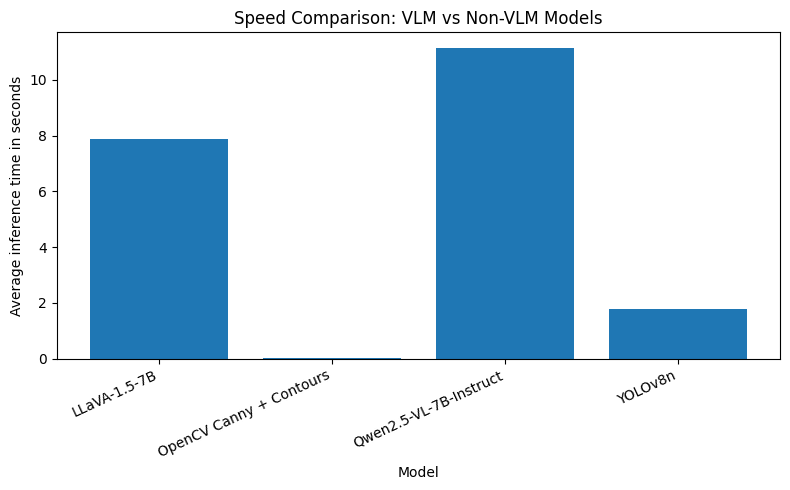

Saved: /kaggle/working/speed_comparison_chart.png


In [18]:
speed_chart_path = base_dir / "speed_comparison_chart.png"

plt.figure(figsize=(8, 5))
plt.bar(table_4["model"], table_4["inference_time_sec"])
plt.xlabel("Model")
plt.ylabel("Average inference time in seconds")
plt.title("Speed Comparison: VLM vs Non-VLM Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(speed_chart_path, dpi=200)
plt.show()

print("Saved:", speed_chart_path)

## 8. Displaying Output Images

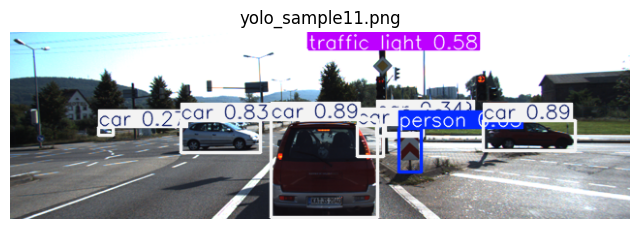

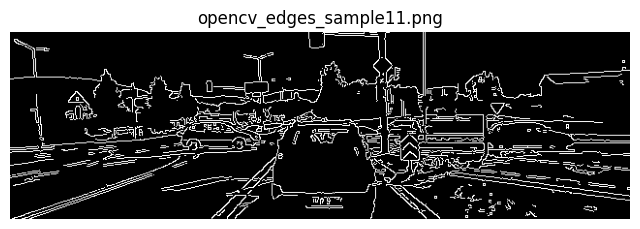

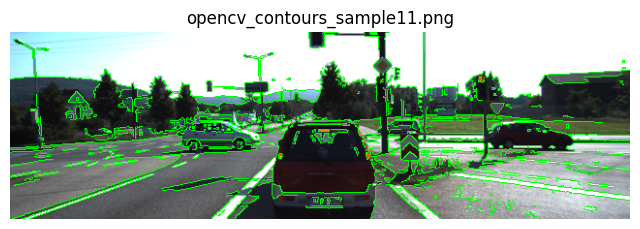

In [19]:
for path in [
    yolo_image_path,
    opencv_edges_path,
    opencv_contours_path,
]:
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.basename(path))
        plt.show()
    else:
        print("Missing:", path)

## 9. Full VLM Outputs

In [21]:
print("-" * 80)
print("QWEN Full Output")
print("-" * 80)
print(qwen_result["main_output"])

print("\n" + "-" * 80)
print("LLAVA Full Output")
print("-" * 80)
print(llava_result["main_output"])

--------------------------------------------------------------------------------
QWEN Full Output
--------------------------------------------------------------------------------
1. **Visible Hazards:**
   - A red car is stopped at the intersection, waiting to turn right.
   - A silver car is approaching from the left, likely turning left.
   - Traffic lights are present but not clearly showing signals.

2. **Road Users and Behaviour:**
   - The red car appears to be cautiously waiting for the right signal to turn.
   - The

--------------------------------------------------------------------------------
LLAVA Full Output
--------------------------------------------------------------------------------
USER:  

Identify visible hazards in this driving scene and recommend what the ego vehicle should do.

Mention:
1. Visible hazards
2. Road users and behaviour
3. Why the scene may be risky
4. Immediate action for the ego vehicle

Be concise.

ASSISTANT: 1. Visible hazards: A red car is st